# Urinalysis Diagnosis Predictive Model
This notebook builds and evaluates classification models to predict urinalysis diagnosis (POSITIVE/NEGATIVE).

**Key considerations:**
- Dataset is heavily imbalanced (~17:1 NEGATIVE to POSITIVE)
- SMOTE is applied to balance training data
- Primary metric is **recall on POSITIVE class** (minimising missed diagnoses)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
urinalysis_data = pd.read_csv(r"datasets/urinalysis_data_cleaned.csv")

In [3]:
urinalysis_data.head()

,Age,Gender,Color,Transparency,Glucose,Protein,pH,Specific Gravity,WBC,RBC,Epithelial Cells,Mucous Threads,Amorphous Urates,Bacteria,Diagnosis
0,76.0,FEMALE,LIGHT YELLOW,CLEAR,NEGATIVE,NEGATIVE,5.0,1.010,1-3,0-2,OCCASIONAL,RARE,NONE SEEN,OCCASIONAL,NEGATIVE
1,9.0,MALE,DARK YELLOW,SLIGHTLY HAZY,NEGATIVE,1+,5.0,1.030,1-3,0-2,RARE,FEW,FEW,MODERATE,NEGATIVE
2,12.0,MALE,LIGHT YELLOW,SLIGHTLY HAZY,NEGATIVE,TRACE,5.0,1.030,0-3,0-2,RARE,FEW,MODERATE,RARE,NEGATIVE
3,77.0,MALE,BROWN,CLOUDY,NEGATIVE,1+,6.0,1.020,5-8,LOADED,RARE,RARE,NONE SEEN,FEW,NEGATIVE
4,29.0,FEMALE,YELLOW,HAZY,NEGATIVE,TRACE,6.0,1.025,1-4,0-2,RARE,RARE,NONE SEEN,FEW,NEGATIVE


In [4]:
urinalysis_data.isna().sum()

Age                 0
Gender              0
Color               0
Transparency        0
Glucose             0
Protein             0
pH                  0
Specific Gravity    0
WBC                 0
RBC                 0
Epithelial Cells    0
Mucous Threads      0
Amorphous Urates    0
Bacteria            0
Diagnosis           0
dtype: int64

## Feature Engineering

In [5]:
X = urinalysis_data.drop(columns=["Diagnosis"])
Y = urinalysis_data["Diagnosis"]

## Train-Test Split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=32)

## Feature Encoding

In [7]:
# Select categorical features
categorical_features = x_train.select_dtypes(include=["object"]).columns.tolist()

In [8]:
# Create instance
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit on training data only
encoder.fit(x_train[categorical_features])

# Transform both datasets
x_train[categorical_features] = encoder.transform(x_train[categorical_features])
x_test[categorical_features] = encoder.transform(x_test[categorical_features])

In [9]:
# FIX: Use .map() instead of .replace() to avoid FutureWarning
y_train = y_train.map({"NEGATIVE": 0, "POSITIVE": 1})
y_test = y_test.map({"NEGATIVE": 0, "POSITIVE": 1})

## Apply SMOTE
SMOTE balances the training set by generating synthetic minority (POSITIVE) samples.
It is applied **after** the train-test split to prevent data leakage.

In [10]:
smote = SMOTE(random_state=42)
x_retrained, y_retrained = smote.fit_resample(x_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_retrained).value_counts())

Class distribution after SMOTE:
Diagnosis
0    1083
1    1083
Name: count, dtype: int64


## Feature Scaling

In [11]:
# Fit scaler on training data only, then transform both sets
scaler = StandardScaler()
x_retrained_scaled = scaler.fit_transform(x_retrained)
x_test_scaled = scaler.transform(x_test)

## Train Models
- Logistic Regression (baseline)
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

In [12]:
logistic_model = LogisticRegression(random_state=42)
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)
xgboost_model = XGBClassifier(random_state=42)

In [13]:
# FIX: Score on recall instead of accuracy — recall is the priority for medical diagnosis
# (minimising missed positives / false negatives)
logistic_scores = cross_val_score(logistic_model, x_retrained_scaled, y_retrained, cv=5, scoring='recall')
decision_tree_scores = cross_val_score(decision_tree_model, x_retrained_scaled, y_retrained, cv=5, scoring='recall')
random_forest_scores = cross_val_score(random_forest_model, x_retrained_scaled, y_retrained, cv=5, scoring='recall')
xgboost_scores = cross_val_score(xgboost_model, x_retrained_scaled, y_retrained, cv=5, scoring='recall')

print("Cross-Validation Recall (POSITIVE class):")
print(f"  Logistic Regression : {logistic_scores.mean():.4f}")
print(f"  Decision Tree       : {decision_tree_scores.mean():.4f}")
print(f"  Random Forest       : {random_forest_scores.mean():.4f}")
print(f"  XGBoost             : {xgboost_scores.mean():.4f}")

Cross-Validation Recall (POSITIVE class):
  Logistic Regression : 0.6685
  Decision Tree       : 0.9428
  Random Forest       : 0.9594
  XGBoost             : 0.9548


In [14]:
# Fit all models on SMOTE-resampled scaled data
logistic_model.fit(x_retrained_scaled, y_retrained)
decision_tree_model.fit(x_retrained_scaled, y_retrained)
random_forest_model.fit(x_retrained_scaled, y_retrained)
xgboost_model.fit(x_retrained_scaled, y_retrained)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Threshold Tuning
The default decision threshold is 0.5. For medical diagnosis, we lower it so the model
is more sensitive to positive cases — catching more true positives at the cost of some false alarms.

In [15]:
THRESHOLD = 0.3  # Tune this between 0.2–0.4 based on acceptable false alarm rate

def predict_with_threshold(model, X, threshold=THRESHOLD):
    proba = model.predict_proba(X)[:, 1]
    return (proba >= threshold).astype(int)

logistic_predictions = predict_with_threshold(logistic_model, x_test_scaled)
decision_tree_predictions = predict_with_threshold(decision_tree_model, x_test_scaled)
random_forest_predictions = predict_with_threshold(random_forest_model, x_test_scaled)
xgboost_predictions = predict_with_threshold(xgboost_model, x_test_scaled)

## Model Evaluation

In [16]:
# Accuracy scores (for reference — not the primary metric)
print("Accuracy Scores (threshold={}):" .format(THRESHOLD))
print(f"  Logistic Regression : {accuracy_score(y_test, logistic_predictions):.4f}")
print(f"  Decision Tree       : {accuracy_score(y_test, decision_tree_predictions):.4f}")
print(f"  Random Forest       : {accuracy_score(y_test, random_forest_predictions):.4f}")
print(f"  XGBoost             : {accuracy_score(y_test, xgboost_predictions):.4f}")

Accuracy Scores (threshold=0.3):
  Logistic Regression : 0.4669
  Decision Tree       : 0.9059
  Random Forest       : 0.9338
  XGBoost             : 0.9477


In [17]:
# Full classification reports — focus on POSITIVE class recall
models = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "XGBoost": xgboost_predictions
}

for name, preds in models.items():
    print(f"{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, preds, target_names=["NEGATIVE", "POSITIVE"]))

 Logistic Regression
              precision    recall  f1-score   support

    NEGATIVE       0.97      0.45      0.61       271
    POSITIVE       0.07      0.75      0.14        16

    accuracy                           0.47       287
   macro avg       0.52      0.60      0.38       287
weighted avg       0.92      0.47      0.59       287

 Decision Tree
              precision    recall  f1-score   support

    NEGATIVE       0.95      0.95      0.95       271
    POSITIVE       0.18      0.19      0.18        16

    accuracy                           0.91       287
   macro avg       0.56      0.57      0.57       287
weighted avg       0.91      0.91      0.91       287

 Random Forest
              precision    recall  f1-score   support

    NEGATIVE       0.97      0.96      0.96       271
    POSITIVE       0.41      0.44      0.42        16

    accuracy                           0.93       287
   macro avg       0.69      0.70      0.69       287
weighted avg       0.94

In [18]:
# FIX: AUC-ROC using predict_proba (probability scores), not hard predictions
print("AUC-ROC Scores (using predicted probabilities):")
for name, model in [("Logistic Regression", logistic_model),
                    ("Decision Tree", decision_tree_model),
                    ("Random Forest", random_forest_model),
                    ("XGBoost", xgboost_model)]:
    proba = model.predict_proba(x_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"  {name:<22}: {auc:.4f}")

AUC-ROC Scores (using predicted probabilities):
  Logistic Regression   : 0.6882
  Decision Tree         : 0.5679
  Random Forest         : 0.7506
  XGBoost               : 0.7315


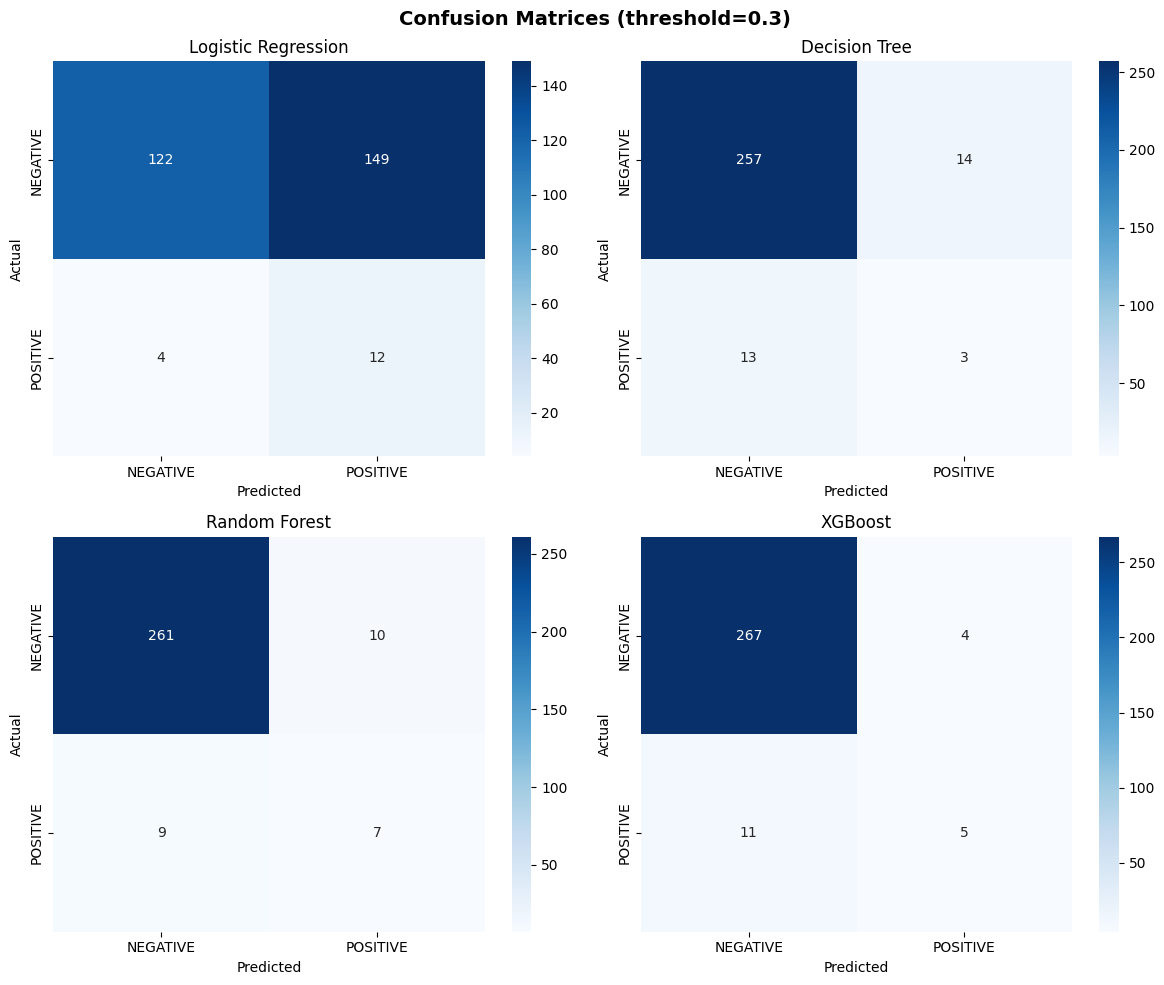

In [19]:
# Confusion Matrix Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"Confusion Matrices (threshold={THRESHOLD})", fontsize=14, fontweight='bold')

for ax, (name, preds) in zip(axes.flat, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=["NEGATIVE", "POSITIVE"],
                yticklabels=["NEGATIVE", "POSITIVE"])
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

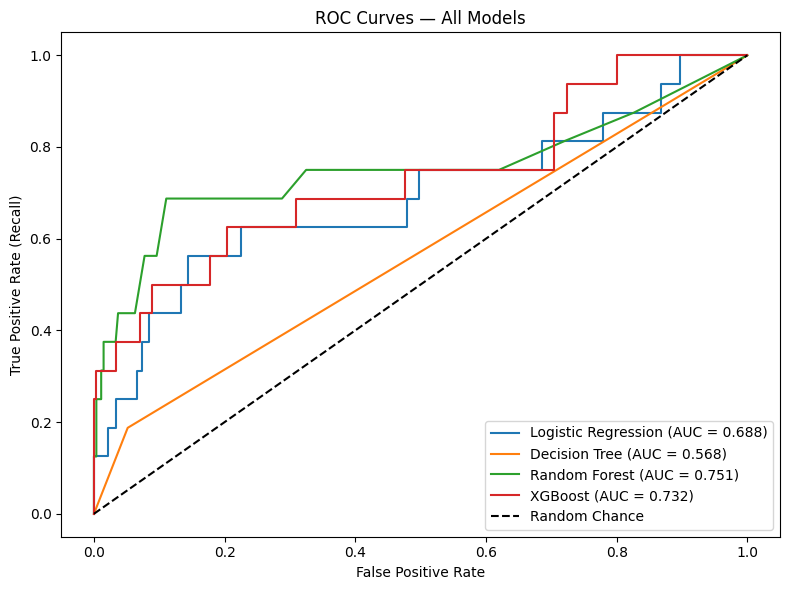

In [ ]:
# ROC Curves for all models
plt.figure(figsize=(8, 6))

for name, model in [("Logistic Regression", logistic_model),
                    ("Decision Tree", decision_tree_model),
                    ("Random Forest", random_forest_model),
                    ("XGBoost", xgboost_model)]:
    proba = model.predict_proba(x_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Hyperparameter tuning

In [22]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, 10, 17, 20]  # 17 = your imbalance ratio
}

xgb_tuned = XGBClassifier(random_state=42)

search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_grid,
    n_iter=50,           # tries 50 random combinations
    scoring='f1',        # optimise for F1
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(x_retrained_scaled, y_retrained)

print("Best parameters:", search.best_params_)
print("Best CV F1:", search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV F1: 0.9667824625249475


In [23]:

# Narrow the grid based on RandomizedSearch results first
param_grid_narrow = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 300],
    'scale_pos_weight': [10, 17, 20]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid=param_grid_narrow,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(x_retrained_scaled, y_retrained)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 10}


In [26]:
best_xgb = search.best_estimator_

# Predict with threshold
proba = best_xgb.predict_proba(x_test_scaled)[:, 1]
tuned_predictions = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, tuned_predictions, target_names=["NEGATIVE", "POSITIVE"]))
print(f"AUC-ROC: {roc_auc_score(y_test, proba):.4f}")

              precision    recall  f1-score   support

    NEGATIVE       0.96      0.98      0.97       271
    POSITIVE       0.45      0.31      0.37        16

    accuracy                           0.94       287
   macro avg       0.71      0.65      0.67       287
weighted avg       0.93      0.94      0.94       287

AUC-ROC: 0.7470
